# Lung Segmentation with U-Net (JSRT Dataset)

## 1. 목적
JSRT 흉부 X-ray 데이터셋을 이용하여 U-Net 기반 폐 영역(segmentation) 모델을 구현하고 의료 영상 분할의 기본 흐름을 이해하는 것을 목표로 합니다.

## 2. 데이터셋
- Dataset: JSRT (Japanese Society of Radiological Technology)
- 입력 이미지: 흉부 X-ray
- 정답 마스크: 폐 영역(binary mask)

## 3. 모델
- Architecture: U-Net
- Task: Binary Segmentation (Lung / Background)


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


In [5]:
import os

IMAGE_DIR = "../datasets/jsrt/content/jsrt/cxr"
MASK_DIR  = "../datasets/jsrt/content/jsrt/masks"

print("Number of images:", len(os.listdir(IMAGE_DIR)))
print("Number of masks :", len(os.listdir(MASK_DIR)))

Number of images: 247
Number of masks : 247


['JPCLN001.png', 'JPCLN002.png', 'JPCLN003.png', 'JPCLN004.png', 'JPCLN005.png']
['JPCLN001.png', 'JPCLN002.png', 'JPCLN003.png', 'JPCLN004.png', 'JPCLN005.png']
Image size: (224, 224) Mask size: (224, 224)


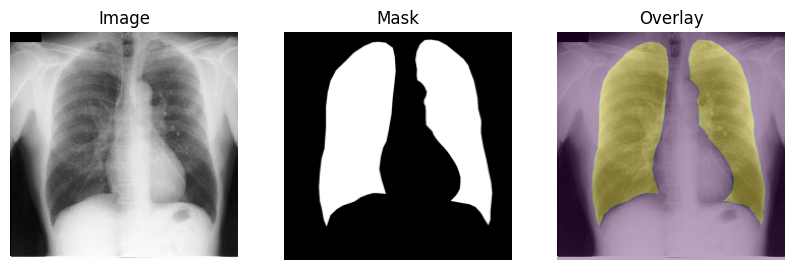

In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "../datasets/jsrt/content/jsrt/cxr"
MASK_DIR  = "../datasets/jsrt/content/jsrt/masks"

# 파일 목록 정렬(이미지/마스크 이름을 맞추기 위해 중요)
img_files  = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(".png")])
mask_files = sorted([f for f in os.listdir(MASK_DIR)  if f.lower().endswith(".png")])

print(img_files[:5])
print(mask_files[:5])

# 하나 샘플 확인
idx = 0
img_path  = os.path.join(IMAGE_DIR, img_files[idx])
mask_path = os.path.join(MASK_DIR,  mask_files[idx])

img  = Image.open(img_path).convert("L")
mask = Image.open(mask_path).convert("L")

print("Image size:", img.size, "Mask size:", mask.size)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Mask"); plt.imshow(mask, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.35)  # 겹쳐보기
plt.axis("off")
plt.show()


In [7]:
import numpy as np

mask_np = np.array(mask)
print("mask unique values (top):", np.unique(mask_np)[:20])
print("mask min/max:", mask_np.min(), mask_np.max())


mask unique values (top): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
mask min/max: 0 255


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

class JSRTSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=256):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.size = size

        self.img_files  = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(".png")])
        self.mask_files = sorted([f for f in os.listdir(mask_dir)  if f.lower().endswith(".png")])

        assert len(self.img_files) == len(self.mask_files), "Image/Mask count mismatch"

        # 기본 변환: 리사이즈 + 텐서화
        self.img_tf  = T.Compose([T.Resize((size, size)), T.ToTensor()])  # [0,1]
        self.mask_tf = T.Compose([T.Resize((size, size)), T.ToTensor()])  # [0,1] 근데 0/1로 정리 필요

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.image_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir,  self.mask_files[idx])

        img  = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img_t  = self.img_tf(img)            # (1,H,W)
        mask_t = self.mask_tf(mask)          # (1,H,W)

        # 마스크를 이진화(0/255 같은 값이면 ToTensor 후 0/1 근처 값이 됩니다)
        mask_t = (mask_t > 0.5).float()

        return img_t, mask_t

dataset = JSRTSegDataset(IMAGE_DIR, MASK_DIR, size=256)
print("Dataset size:", len(dataset))

# train/val split (예: 8:2)
train_size = int(len(dataset) * 0.8)
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

x, y = next(iter(train_loader))
print("batch x:", x.shape, x.dtype, "range:", (x.min().item(), x.max().item()))
print("batch y:", y.shape, y.dtype, "unique:", torch.unique(y))

Dataset size: 247
batch x: torch.Size([8, 1, 256, 256]) torch.float32 range: (0.0, 1.0)
batch y: torch.Size([8, 1, 256, 256]) torch.float32 unique: tensor([0., 1.])


In [9]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


In [29]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-3


device: mps


In [31]:
import torch.nn as nn
import torch

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(64,128,256,512)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        rev = list(reversed(features))
        up_in = features[-1]*2
        for f in rev:
            self.ups.append(nn.ConvTranspose2d(up_in, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(up_in, f))
            up_in = f

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i//2]

            if x.shape[-2:] != skip.shape[-2:]:
                x = torch.nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)

        return self.final(x)

model = UNet(in_channels=1, out_channels=1).to(device)
print("model ready")


model ready


In [32]:
from tqdm import tqdm

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou  = 0.0
    n = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = bce(logits, y) + dice_loss(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coef(logits.detach(), y.detach())
        total_iou  += iou_score(logits.detach(), y.detach())
        n += 1

    return total_loss/n, total_dice/n, total_iou/n

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_dice, tr_iou = run_epoch(train_loader, train=True)
    va_loss, va_dice, va_iou = run_epoch(val_loader, train=False)

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train loss {tr_loss:.4f} dice {tr_dice:.4f} iou {tr_iou:.4f} | "
          f"val loss {va_loss:.4f} dice {va_dice:.4f} iou {va_iou:.4f}")


[01/10] train loss 0.6236 dice 0.8401 iou 0.7435 | val loss 0.9587 dice 0.6912 iou 0.5309


[02/10] train loss 0.3183 dice 0.9408 iou 0.8893 | val loss 0.3606 dice 0.9181 iou 0.8504


[03/10] train loss 0.2175 dice 0.9527 iou 0.9103 | val loss 0.2001 dice 0.9586 iou 0.9209


[04/10] train loss 0.1618 dice 0.9609 iou 0.9252 | val loss 0.1505 dice 0.9631 iou 0.9291


[05/10] train loss 0.1301 dice 0.9665 iou 0.9355 | val loss 0.1170 dice 0.9698 iou 0.9416


[06/10] train loss 0.1082 dice 0.9705 iou 0.9428 | val loss 0.1138 dice 0.9690 iou 0.9403


[07/10] train loss 0.1052 dice 0.9692 iou 0.9404 | val loss 0.1054 dice 0.9696 iou 0.9413


[08/10] train loss 0.0955 dice 0.9713 iou 0.9445 | val loss 0.0908 dice 0.9731 iou 0.9479


[09/10] train loss 0.0852 dice 0.9741 iou 0.9496 | val loss 0.0830 dice 0.9744 iou 0.9503


[10/10] train loss 0.0804 dice 0.9749 iou 0.9511 | val loss 0.0780 dice 0.9753 iou 0.9521
